# Euro-SAM 2026 — graph learning for sparse sewer monitoring
Uses only `ouseburn_dataset/` written by **Euro_SAM_v1** (no extra installs: PyTorch is pre-installed on Colab).

Optional: *Runtime → Change runtime type → T4 GPU* for faster training (do this before running anything; it restarts the session).


In [1]:
# Mount Google Drive and move into the project folder.
# Each collaborator sets PROJECT to where the shared "Euro-SAM 2026" folder
# (or a clone of the GitHub repository) lives on THEIR Drive.
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT = "/content/drive/MyDrive/Colab Notebooks/Euro-SAM 2026"
os.chdir(PROJECT)
print("Working in:", os.getcwd())
print(sorted(os.listdir(".")))


Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/Euro-SAM 2026
 cache			  Euro_SAM_v1.ipynb	 ouseburn_gnn
 Euro_SAM_GNN.ipynb	  ouseburn_config.yml	 ouseburn_output
'Euro_SAM_GNN v0.ipynb'   ouseburn_dataset	 ouseburn_scenarios.py
'Euro-SAM v0.ipynb'	  ouseburn_diagnose.py


## Settings and functions
Running this cell only defines things. Settings are at the top.


In [2]:
"""
Ouseburn — graph learning for sparse sewer monitoring (step 5)
==============================================================
From the ~5 % monitored manholes, infer at every UNMONITORED manhole:
  * the deviation from expected behaviour (Δdepth, Δinflow), and
  * the probability that the manhole is affected by a disturbance
    (the "likelihood map" of the issue across the network).

"Expected behaviour" = the hydraulic model's normal run under the same rain
(a digital-twin baseline); a deviation = observed - expected.

Methods compared at sensor densities 2 / 5 / 10 / 20 %:
  IDW        graph-distance interpolation of sensor deviations (no learning)
  GNN-topo   graph neural network on connectivity only (undirected)
  GNN-hydro  hydraulically-informed GNN: flow direction (separate upstream /
             downstream messages), pipe properties gate the messages, and the
             model's expected depth/inflow are node inputs

Test protocol: event-wise cross-validation. Rain events are split into
N_FOLDS groups; each fold holds one group out for testing (and one event for
validation / early stopping / threshold tuning), so every event - and every
disturbance - is tested exactly once by a model that never saw it. Per fold,
one model per method is trained with sensor densities drawn at random between
2 % and 20 % (nested placement), then evaluated per density. Results are
pooled over folds (fold-to-fold spread = error bars) and GNN-hydro vs
GNN-topo is compared with a paired bootstrap over test disturbances.

Needs only the dataset folder written by the scenario step. Uses PyTorch
(pre-installed on Colab; GPU used if available).
"""

from __future__ import annotations

import json
import time
from pathlib import Path

import networkx as nx
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

# =============================================================================
# SETTINGS
# =============================================================================
DATASET_DIR = Path("ouseburn_dataset")
OUT_DIR = Path("ouseburn_gnn")
SEED = 0

DENSITIES = (0.02, 0.05, 0.10, 0.20)   # evaluated sensor densities
TRAIN_DENSITY = (0.02, 0.20)           # densities sampled during training
HEADLINE_DENSITY = 0.05
N_FOLDS, VAL_EVENTS = 4, 1             # event-wise cross-validation
N_BOOT = 2000                          # bootstrap resamples (hydro vs topo)

LAGS = 3                    # sensor readings at t, t-1, t-2
HIDDEN, LAYERS = 64, 8      # 8 message-passing steps ~ reach 8 pipes away
EPOCHS, BATCH, LR, PATIENCE = 60, 16, 2e-3, 10   # early stop on validation avg. precision

DEPTH_THR = 0.05            # "affected": |Δdepth| > 5 cm …
FLOW_ABS, FLOW_REL = 0.5, 0.10   # … or |Δinflow| > max(0.5 L/s, 10 % of normal peak)
DEPTH_SCALE, FLOW_SCALE = 0.10, 5.0   # m, L/s used to scale deviations

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# =============================================================================
# 1. DATA
# =============================================================================
def load_dataset():
    nodes = pd.read_csv(DATASET_DIR / "nodes.csv", dtype={"node_id": str})
    edges = pd.read_csv(DATASET_DIR / "edges.csv", dtype={"link_id": str, "u": str, "v": str})
    sc = pd.read_csv(DATASET_DIR / "scenarios.csv")
    z = np.load(DATASET_DIR / "timeseries.npz")
    if list(z["node_ids"].astype(str)) != nodes.node_id.tolist():
        raise ValueError("timeseries node order does not match nodes.csv")
    if "link_type" not in edges:
        edges["link_type"] = "conduit"

    pos = {sid: i for i, sid in enumerate(z["scenario_ids"])}
    sc["row"] = sc.scenario_id.map(pos)
    sc["base_row"] = sc.baseline_id.map(pos)
    ok = sc.set_index("scenario_id").qa_ok.astype(bool)
    sc = sc[sc.qa_ok.astype(bool) & sc.baseline_id.map(ok).fillna(False).astype(bool)].reset_index(drop=True)

    depth, inflow = z["depth"].astype(np.float32), z["inflow"].astype(np.float32)
    r, b = sc.row.values, sc.base_row.values
    d = dict(
        res_d=np.nan_to_num(depth[r] - depth[b]),
        res_q=np.nan_to_num(inflow[r] - inflow[b]),
        base_d=np.nan_to_num(depth[b]),
        base_q=np.nan_to_num(inflow[b]),
    )
    qref = np.abs(d["base_q"]).max(axis=1, keepdims=True)                # (S,1,N)
    d["label"] = ((np.abs(d["res_d"]) > DEPTH_THR) |
                  (np.abs(d["res_q"]) > np.maximum(FLOW_ABS, FLOW_REL * qref))).astype(np.float32)
    d["label"][(sc.kind == "normal").values] = 0.0
    return nodes, edges, sc, d


def build_graph(nodes, edges):
    idx = {n: i for i, n in enumerate(nodes.node_id)}
    e = edges[edges.u.isin(idx) & edges.v.isin(idx)].reset_index(drop=True)
    src = torch.tensor(e.u.map(idx).values)
    dst = torch.tensor(e.v.map(idx).values)
    N = len(nodes)

    # edge features: pipe size, gradient, length, pump flag
    pump = (e.link_type == "pump").astype(float).values
    ef = np.stack([np.log(e.diameter.fillna(0.15).clip(lower=0.05)),
                   np.clip(e.slope.fillna(0), -0.2, 0.5) * (1 - pump),
                   np.log1p(e.length.fillna(10)), pump], 1)
    ef = (ef - ef.mean(0)) / (ef.std(0) + 1e-6)

    # static node features
    is_out = (nodes.kind == "outfall").values.astype(float)
    out_d = e.groupby(e.u.map(idx)).diameter.max().reindex(range(N)).fillna(0.15).values
    wetwell = np.isin(np.arange(N), e[e.link_type == "pump"].u.map(idx).values).astype(float)
    xs = np.stack([np.log1p(nodes.upstream_area_ha.fillna(0)), np.log1p(nodes.n_upstream.fillna(0)),
                   nodes.max_depth.fillna(0), nodes.surface_elev.fillna(nodes.invert) - nodes.invert.min(),
                   is_out, nodes.is_outlet_manhole.astype(float), wetwell, np.log(out_d)], 1)
    xs = (xs - xs.mean(0)) / (xs.std(0) + 1e-6)

    G = nx.Graph(); G.add_nodes_from(range(N)); G.add_edges_from(zip(src.tolist(), dst.tolist()))
    hops = dict(nx.all_pairs_shortest_path_length(G))
    H = np.full((N, N), 999, dtype=np.int32)
    for i, dd in hops.items():
        H[i, list(dd)] = list(dd.values())

    D = nx.DiGraph(); D.add_nodes_from(range(N)); D.add_edges_from(zip(src.tolist(), dst.tolist()))
    anc = np.zeros((N, N), dtype=bool)                  # anc[i, j]: j is upstream of i
    for i in range(N):
        anc[i, list(nx.ancestors(D, i))] = True

    rank = nodes.sensor_rank.values
    n_mh = int((nodes.kind == "manhole").sum())
    return dict(src=src, dst=dst, ef=torch.tensor(ef, dtype=torch.float32), anc=anc,
                xs=torch.tensor(xs, dtype=torch.float32), N=N, hops=H, idx=idx,
                rank=np.where(np.isnan(rank), np.inf, rank), n_mh=n_mh,
                max_depth=nodes.max_depth.fillna(1).clip(lower=0.5).values.astype(np.float32))


def sensor_mask(g, density) -> np.ndarray:
    return (g["rank"] < round(density * g["n_mh"])).astype(np.float32)


def make_folds(sc, rng):
    """One 'part' array (train/val/test per run) per fold; each event tested once."""
    ev = np.array(sorted(sc.event_id.unique()))
    rng.shuffle(ev)
    groups = np.array_split(ev, N_FOLDS)
    folds = []
    for k in range(N_FOLDS):
        test = set(groups[k])
        val = set(groups[(k + 1) % N_FOLDS][:VAL_EVENTS])
        folds.append(sc.event_id.map(
            lambda e: "test" if e in test else "val" if e in val else "train").values)
    return folds


# =============================================================================
# 2. FEATURES
# =============================================================================
def make_inputs(T, g, s_idx, t_idx, masks, hydro: bool):
    """Node inputs for a batch of (scenario, time, sensor mask). Returns (B,N,F)."""
    B, N = len(s_idx), g["N"]
    m = masks                                                     # (B,N)
    feats = [m]
    for lag in range(LAGS):
        tt = np.clip(t_idx - lag, 0, None)
        valid = (t_idx - lag >= 0)[:, None].astype(np.float32)
        feats.append(T["res_d"][s_idx, tt] / DEPTH_SCALE * m * valid)
        feats.append(T["res_q"][s_idx, tt] / FLOW_SCALE * m * valid)
    if hydro:   # expected (model) state at every node
        feats.append(T["base_d"][s_idx, t_idx] / g["max_depth"])
        feats.append(np.log1p(np.abs(T["base_q"][s_idx, t_idx])))
    x = np.stack(feats, -1).astype(np.float32)
    x = np.clip(x, -20, 20)
    xs = g["xs"].numpy()[None].repeat(B, 0)
    return torch.tensor(np.concatenate([x, xs], -1))


# =============================================================================
# 3. MODELS
# =============================================================================
class Layer(nn.Module):
    def __init__(self, h, hydro, edge_dim):
        super().__init__()
        self.hydro = hydro
        self.self_lin = nn.Linear(h, h)
        self.up = nn.Linear(h, h)                 # messages travelling downstream (u -> v)
        self.down = nn.Linear(h, h) if hydro else None   # messages travelling upstream (v -> u)
        self.gate = nn.Sequential(nn.Linear(edge_dim, 16), nn.ReLU(), nn.Linear(16, 2)) if hydro else None
        self.norm = nn.LayerNorm(h)

    def forward(self, H, g):
        src, dst = g["src_d"], g["dst_d"]
        B, N, h = H.shape
        if self.hydro:
            w = torch.sigmoid(self.gate(g["ef_d"]))                  # (E,2)
            m_dn = torch.zeros_like(H).index_add_(1, dst, self.up(H)[:, src] * w[:, 0, None])
            m_up = torch.zeros_like(H).index_add_(1, src, self.down(H)[:, dst] * w[:, 1, None])
            msg = m_dn / g["deg_in"] + m_up / g["deg_out"]
        else:
            Hm = self.up(H)
            msg = (torch.zeros_like(H).index_add_(1, dst, Hm[:, src])
                   .index_add_(1, src, Hm[:, dst])) / g["deg"]
        return self.norm(H + F.relu(self.self_lin(H) + msg))


class GNN(nn.Module):
    def __init__(self, f_in, hydro, edge_dim):
        super().__init__()
        self.inp = nn.Linear(f_in, HIDDEN)
        self.layers = nn.ModuleList(Layer(HIDDEN, hydro, edge_dim) for _ in range(LAYERS))
        self.head = nn.Sequential(nn.Linear(HIDDEN, HIDDEN), nn.ReLU(), nn.Linear(HIDDEN, 3))

    def forward(self, x, g):
        H = F.relu(self.inp(x))
        for layer in self.layers:
            H = layer(H, g)
        return self.head(H)            # Δdepth (scaled), Δinflow (scaled), logit(affected)


def device_graph(g):
    N = g["N"]
    src, dst = g["src"].to(DEVICE), g["dst"].to(DEVICE)
    ones = torch.ones(len(src), device=DEVICE)
    deg_in = torch.zeros(N, device=DEVICE).index_add_(0, dst, ones).clamp(min=1)
    deg_out = torch.zeros(N, device=DEVICE).index_add_(0, src, ones).clamp(min=1)
    return dict(src_d=src, dst_d=dst, ef_d=g["ef"].to(DEVICE),
                deg_in=deg_in[None, :, None], deg_out=deg_out[None, :, None],
                deg=(deg_in + deg_out)[None, :, None])


def train_model(name, hydro, T, g, part, sc, rng):
    gd = device_graph(g)
    f_in = make_inputs(T, g, np.array([0]), np.array([0]), np.zeros((1, g["N"]), np.float32), hydro).shape[-1]
    model = GNN(f_in, hydro, g["ef"].shape[1]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    S, Tn = T["res_d"].shape[:2]
    tr = np.where(part == "train")[0]; va = np.where(part == "val")[0]
    pos_rate = T["label"][tr].mean()
    # sqrt of the class ratio: enough to learn the rare "affected" class without
    # making probabilities over-confident (cut-off is tuned on validation anyway)
    pos_w = torch.tensor(min(10.0, np.sqrt((1 - pos_rate) / max(pos_rate, 1e-4))), device=DEVICE)

    def batch_loss(s_idx, t_idx, dens, train=True):
        masks = np.stack([sensor_mask(g, d) for d in dens])
        x = make_inputs(T, g, s_idx, t_idx, masks, hydro).to(DEVICE)
        y_d = torch.tensor(T["res_d"][s_idx, t_idx] / DEPTH_SCALE, device=DEVICE)
        y_q = torch.tensor(T["res_q"][s_idx, t_idx] / FLOW_SCALE, device=DEVICE)
        y_a = torch.tensor(T["label"][s_idx, t_idx], device=DEVICE)
        w = torch.tensor(1 - masks, device=DEVICE)                 # unmonitored nodes only
        out = model(x, gd)
        l = (F.huber_loss(out[..., 0], y_d.clamp(-20, 20), reduction="none") +
             F.huber_loss(out[..., 1], y_q.clamp(-20, 20), reduction="none") +
             F.binary_cross_entropy_with_logits(out[..., 2], y_a, pos_weight=pos_w, reduction="none"))
        return (l * w).sum() / w.sum()

    pairs = np.array([(s, t) for s in tr for t in range(Tn)])
    best, best_state, bad, best_ep = -np.inf, None, 0, 0
    t0 = time.time()
    for ep in range(EPOCHS):
        model.train(); rng.shuffle(pairs); tot = 0
        for i in range(0, len(pairs), BATCH):
            b = pairs[i:i + BATCH]
            dens = rng.uniform(*TRAIN_DENSITY, len(b))
            loss = batch_loss(b[:, 0], b[:, 1], dens)
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            tot += loss.item() * len(b)
        model.eval()
        vap = val_avg_precision(lambda s, d: predict_gnn(model, gd, hydro, T, g, s, d), T, g, sc, va)
        if vap > best + 1e-4:
            best, bad, best_ep = vap, 0, ep + 1
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
        print(f"\r  {name}: epoch {ep + 1:>2}/{EPOCHS}  train loss {tot / len(pairs):.4f}  "
              f"val AP {vap:.3f} (best {best:.3f} @ {best_ep})  ({time.time() - t0:.0f}s)",
              end="", flush=True)
        if bad >= PATIENCE:
            break
    print()
    model.load_state_dict(best_state)
    return model, gd


# =============================================================================
# 4. PREDICTION + BASELINE
# =============================================================================
@torch.no_grad()
def predict_gnn(model, gd, hydro, T, g, s, density):
    Tn = T["res_d"].shape[1]
    m = np.repeat(sensor_mask(g, density)[None], Tn, 0)
    x = make_inputs(T, g, np.full(Tn, s), np.arange(Tn), m, hydro).to(DEVICE)
    out = model.eval()(x, gd).cpu().numpy()
    return dict(prob=1 / (1 + np.exp(-out[..., 2])), d=out[..., 0] * DEPTH_SCALE, q=out[..., 1] * FLOW_SCALE)


def predict_idw(T, g, s, density, qref):
    """Inverse (hop-distance)^2 weighting of sensor deviations, same system only."""
    m = sensor_mask(g, density).astype(bool)
    H = g["hops"][:, m].astype(float)                       # (N, n_sensors)
    W = np.where(H < 999, 1.0 / (1.0 + H) ** 2, 0.0)
    W = W / np.maximum(W.sum(1, keepdims=True), 1e-9)
    d = T["res_d"][s][:, m] @ W.T
    q = T["res_q"][s][:, m] @ W.T
    score = np.maximum(np.abs(d) / DEPTH_THR, np.abs(q) / np.maximum(FLOW_ABS, FLOW_REL * qref))
    return dict(prob=np.clip(score / 2, 0, 1), d=d, q=q)    # score 1 (threshold) -> prob 0.5


# =============================================================================
# 5. EVALUATION
# =============================================================================
def locate_source(p, g, thr):
    """Most upstream manhole of the predicted affected zone (ties: highest probability).

    A disturbance's effect is carried downstream by the flow, so its source is
    where the affected zone starts. Falls back to the most likely node.
    """
    pm = p["prob"].max(0)
    A = pm > thr
    if not A.any():
        return int(np.argmax(pm))
    heads = np.where(A & ~(g["anc"][:, A].any(1)))[0]     # affected, no affected upstream
    return int(heads[np.argmax(pm[heads])])


def val_avg_precision(pred, T, g, sc, runs):
    """Mean (over densities) average precision on validation disturbances."""
    from sklearn.metrics import average_precision_score
    out = []
    for dens in DENSITIES:
        um = ~sensor_mask(g, dens).astype(bool)
        yt, sp = [], []
        for s in runs:
            if sc.kind.iloc[s] == "normal":
                continue
            yt.append(T["label"][s].max(0)[um] > 0)
            sp.append(pred(s, dens)["prob"].max(0)[um])
        yt, sp = np.concatenate(yt), np.concatenate(sp)
        if yt.any():
            out.append(average_precision_score(yt, sp))
    return float(np.mean(out)) if out else 0.0


def tune_threshold(preds_fn, T, g, sc, part):
    """Probability cut-off maximising F1 on the VALIDATION events (all densities pooled)."""
    qref_all = np.abs(T["base_q"]).max(axis=1)
    yt, sp = [], []
    for dens in DENSITIES:
        um = ~sensor_mask(g, dens).astype(bool)
        for s in np.where(part == "val")[0]:
            if sc.kind.iloc[s] == "normal":
                continue
            yt.append(T["label"][s].max(0)[um] > 0)
            sp.append(preds_fn(s, dens, qref_all[s])["prob"].max(0)[um])
    yt, sp = np.concatenate(yt), np.concatenate(sp)
    if not yt.any():
        return 0.5
    best = max(np.linspace(0.05, 0.99, 48),
               key=lambda t: 2 * (yt & (sp > t)).sum() / max((sp > t).sum() + yt.sum(), 1))
    return float(best)


def collect(preds_fn, T, g, sc, runs, thr):
    """Per-run records at every density (unmonitored manholes only)."""
    qref_all = np.abs(T["base_q"]).max(axis=1)
    recs = []
    for dens in DENSITIES:
        um = ~sensor_mask(g, dens).astype(bool)
        for s in runs:
            p = preds_fn(s, dens, qref_all[s])
            prob = p["prob"].max(0)[um]
            r = dict(density=dens, run=int(s), kind=sc.kind.iloc[s],
                     true=T["label"][s].max(0)[um] > 0, prob=prob, pred=prob > thr, hops=np.nan)
            if r["kind"] != "normal" and T["label"][s].max() > 0:
                tgt = str(sc.target.iloc[s])
                src_node = tgt.split("-")[0] if r["kind"] == "blockage" else tgt
                if src_node in g["idx"]:
                    r["hops"] = min(g["hops"][locate_source(p, g, thr), g["idx"][src_node]], 99)
            recs.append(r)
    return recs


def summarise(recs):
    from sklearn.metrics import average_precision_score
    dis = [r for r in recs if r["kind"] != "normal"]
    nor = [r for r in recs if r["kind"] == "normal"]
    yt = np.concatenate([r["true"] for r in dis]); yp = np.concatenate([r["pred"] for r in dis])
    sp = np.concatenate([r["prob"] for r in dis])
    tp = (yt & yp).sum(); prec = tp / max(yp.sum(), 1); rec = tp / max(yt.sum(), 1)
    hops = np.array([r["hops"] for r in dis if not np.isnan(r["hops"])])
    return dict(precision=prec, recall=rec, f1=2 * prec * rec / max(prec + rec, 1e-9),
                avg_precision=average_precision_score(yt, sp) if yt.any() else np.nan,
                false_alarm_normal=np.mean([r["pred"].mean() for r in nor]) if nor else np.nan,
                loc_within_2_hops=(hops <= 2).mean() if len(hops) else np.nan,
                loc_median_hops=np.median(hops) if len(hops) else np.nan,
                n_disturbances=len(dis), n_localisable=len(hops))


def bootstrap_compare(recs_a, recs_b, rng, label_a="GNN-hydro", label_b="GNN-topo"):
    """Paired bootstrap over test disturbances: metric(a) - metric(b) per density."""
    rows = []
    for dens in DENSITIES:
        A = [r for r in recs_a if r["density"] == dens and r["kind"] != "normal"]
        B = [r for r in recs_b if r["density"] == dens and r["kind"] != "normal"]
        assert [r["run"] for r in A] == [r["run"] for r in B]
        diffs = {m: [] for m in ("f1", "avg_precision", "loc_within_2_hops")}
        for _ in range(N_BOOT):
            i = rng.integers(0, len(A), len(A))
            sa, sb = summarise([A[j] for j in i]), summarise([B[j] for j in i])
            for m in diffs:
                diffs[m].append(sa[m] - sb[m])
        base_a, base_b = summarise(A), summarise(B)
        for m, d in diffs.items():
            d = np.array(d, float); d = d[~np.isnan(d)]
            rows.append(dict(density=dens, metric=m, **{label_a: base_a[m], label_b: base_b[m]},
                             diff=base_a[m] - base_b[m], ci95_low=np.percentile(d, 2.5),
                             ci95_high=np.percentile(d, 97.5), p_a_not_better=(d <= 0).mean()))
    return pd.DataFrame(rows)


# =============================================================================
# 6. FIGURES
# =============================================================================
def plot_results(res, nodes, edges, g, T, sc, part, preds, out_dir):
    import matplotlib.pyplot as plt
    from matplotlib.collections import LineCollection

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    pooled, spread = res
    for meth, grp in pooled.groupby("method", sort=False):
        x = grp.density * 100
        sd = spread[spread.method == meth].set_index("density")
        for ax, col, k in ((axes[0], "f1", 1), (axes[1], "avg_precision", 1), (axes[2], "loc_within_2_hops", 100)):
            ax.errorbar(x, grp[col] * k, yerr=sd[col].reindex(grp.density).values * k,
                        fmt="o-", capsize=3, label=meth)
    for ax, t in zip(axes, ["F1 - affected unmonitored manholes", "Average precision (likelihood map)",
                            "Source located within 2 pipes (%)"]):
        ax.set_xlabel("Sensor density (% of manholes)"); ax.set_title(t, fontsize=10)
        ax.set_xticks([d * 100 for d in DENSITIES]); ax.grid(alpha=.3)
    axes[0].legend(fontsize=8)
    fig.text(0.5, -0.02, f"Pooled over {N_FOLDS} event-wise cross-validation folds; "
             "error bars = std across folds", ha="center", fontsize=9)
    fig.tight_layout(); fig.savefig(out_dir / "results_by_density.png", dpi=150, bbox_inches="tight"); plt.close(fig)

    # example likelihood map: a typical test disturbance at the headline density
    test = [s for s in np.where(part == "test")[0]
            if sc.kind.iloc[s] != "normal" and T["label"][s].max() > 0]
    if test:
        s = sorted(test, key=lambda s: T["label"][s].max(0).sum())[len(test) // 2]
        plot_example_map(nodes, g, T, sc, s, preds(s), HEADLINE_DENSITY, out_dir / "example_likelihood_map.png")


def plot_example_map(nodes, g, T, sc, s, preds, density, path):
    """Truth vs each method's P(affected). Sensors are drawn with what they MEASURE
    (they are observed, not predicted), so only unmonitored manholes show predictions."""
    import matplotlib.pyplot as plt
    from matplotlib.collections import LineCollection
    xy = nodes[["x", "y"]].values
    segs = [[xy[a], xy[b]] for a, b in zip(g["src"].tolist(), g["dst"].tolist())]
    m = sensor_mask(g, density).astype(bool)
    true = T["label"][s].max(0)
    tgt = str(sc.target.iloc[s]); src = tgt.split("-")[0] if sc.kind.iloc[s] == "blockage" else tgt
    panels = [("Truth: affected manholes", true)] + [(f"{k}: P(affected)", v["prob"].max(0))
                                                    for k, v in preds.items()]
    fig, axes = plt.subplots(1, len(panels), figsize=(4.6 * len(panels), 5), constrained_layout=True)
    for ax, (title, val) in zip(axes, panels):
        ax.add_collection(LineCollection(segs, colors="#c8d4e0", linewidths=0.8))
        um = ~m
        sca = ax.scatter(xy[um, 0], xy[um, 1], c=val[um], cmap="Reds", vmin=0, vmax=1, s=10, zorder=2)
        ax.scatter(xy[m, 0], xy[m, 1], marker="s", s=55, c=np.where(true[m] > 0, "#7a0010", "white"),
                   edgecolors="k", lw=1, zorder=3)
        if src in g["idx"]:
            ax.scatter(*xy[g["idx"][src]], marker="*", s=260, c="gold", edgecolor="k", zorder=4)
        ax.set_title(title, fontsize=10); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
        ax.autoscale()
    fig.colorbar(sca, ax=axes, shrink=0.7, label="truth / P(affected)  (unmonitored manholes)")
    fig.suptitle(f"Test scenario {sc.scenario_id.iloc[s]}: {sc.kind.iloc[s]} at {sc.target.iloc[s]} (★) - "
                 f"{density:.0%} sensors (■ dark = sensor measures a deviation)", fontsize=11)
    fig.savefig(path, dpi=150, bbox_inches="tight"); plt.close(fig)


def replot_example(scenario_id=None, density=None, fname="example_likelihood_map.png"):
    """Redraw the example map from the SAVED fold models (no retraining).

    scenario_id=None picks a typical test disturbance (median affected size)."""
    density = density or HEADLINE_DENSITY
    torch.manual_seed(SEED); rng = np.random.default_rng(SEED)
    nodes, edges, sc, T = load_dataset(); g = build_graph(nodes, edges)
    folds = make_folds(sc, rng)                       # same folds as run_experiment
    if scenario_id is None:
        cand = [s for s in range(len(sc)) if sc.kind.iloc[s] != "normal" and T["label"][s].max() > 0]
        s = sorted(cand, key=lambda s: T["label"][s].max(0).sum())[len(cand) // 2]
    else:
        s = int(np.where(sc.scenario_id.values == scenario_id)[0][0])
    k = next(i for i, part in enumerate(folds) if part[s] == "test")
    gd = device_graph(g)
    qref = np.abs(T["base_q"]).max(axis=1)[s]
    preds = {"IDW": predict_idw(T, g, s, density, qref)}
    for name, hydro in (("GNN-topo", False), ("GNN-hydro", True)):
        f_in = make_inputs(T, g, np.array([0]), np.array([0]), np.zeros((1, g["N"]), np.float32), hydro).shape[-1]
        mdl = GNN(f_in, hydro, g["ef"].shape[1]).to(DEVICE)
        mdl.load_state_dict(torch.load(OUT_DIR / f"{name}_fold{k + 1}.pt", map_location=DEVICE))
        preds[name] = predict_gnn(mdl, gd, hydro, T, g, s, density)
    plot_example_map(nodes, g, T, sc, s, preds, density, OUT_DIR / fname)
    print(f"Scenario {sc.scenario_id.iloc[s]} ({sc.kind.iloc[s]} at {sc.target.iloc[s]}), "
          f"tested in fold {k + 1}; saved {OUT_DIR / fname}")
    return OUT_DIR / fname


# =============================================================================
# 7. MAIN
# =============================================================================
def run_experiment():
    torch.manual_seed(SEED); rng = np.random.default_rng(SEED)
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    nodes, edges, sc, T = load_dataset()
    g = build_graph(nodes, edges)
    folds = make_folds(sc, rng)
    print(f"Device {DEVICE}; {len(sc)} runs (qa_ok), {g['N']} nodes, {len(g['src'])} links; "
          f"{sc.event_id.nunique()} events, {N_FOLDS}-fold event-wise cross-validation")
    print(f"Affected node-times: {T['label'].mean():.2%}")

    recs = {m: [] for m in ("IDW", "GNN-topo", "GNN-hydro")}
    fold_rows, last = [], None
    for k, part in enumerate(folds):
        print(f"\nFold {k + 1}/{N_FOLDS}: test events {sorted(set(sc.event_id[part == 'test']))}, "
              f"val {sorted(set(sc.event_id[part == 'val']))}")
        fns = {"IDW": lambda s, d, q: predict_idw(T, g, s, d, q)}
        for name, hydro in (("GNN-topo", False), ("GNN-hydro", True)):
            mdl, gd = train_model(name, hydro, T, g, part, sc, rng)
            torch.save(mdl.state_dict(), OUT_DIR / f"{name}_fold{k + 1}.pt")
            fns[name] = (lambda mdl, gd, hydro: lambda s, d, q: predict_gnn(mdl, gd, hydro, T, g, s, d))(mdl, gd, hydro)
        thr = {m: tune_threshold(f, T, g, sc, part) for m, f in fns.items()}
        print("  thresholds:", {m: round(v, 2) for m, v in thr.items()})
        test_runs = np.where(part == "test")[0]
        for m, f in fns.items():
            r = collect(f, T, g, sc, test_runs, thr[m])
            recs[m] += r
            for dens in DENSITIES:
                fold_rows.append(dict(fold=k + 1, method=m, density=dens, threshold=thr[m],
                                      **summarise([x for x in r if x["density"] == dens])))
        last = (fns, part)

    by_fold = pd.DataFrame(fold_rows)
    pooled = pd.DataFrame([dict(method=m, density=d, **summarise([r for r in recs[m] if r["density"] == d]))
                           for m in recs for d in DENSITIES])
    spread = by_fold.groupby(["method", "density"])[["f1", "avg_precision", "loc_within_2_hops"]].std().reset_index()
    comp = bootstrap_compare(recs["GNN-hydro"], recs["GNN-topo"], rng)
    by_fold.to_csv(OUT_DIR / "results_by_fold.csv", index=False)
    pooled.to_csv(OUT_DIR / "results_pooled.csv", index=False)
    comp.to_csv(OUT_DIR / "hydro_vs_topo_bootstrap.csv", index=False)

    qref_all = np.abs(T["base_q"]).max(axis=1)
    fns, part = last
    plot_results((pooled, spread), nodes, edges, g, T, sc, part,
                 lambda s: {k: f(s, HEADLINE_DENSITY, qref_all[s]) for k, f in fns.items()}, OUT_DIR)
    (OUT_DIR / "config.json").write_text(json.dumps(
        {k: v for k, v in globals().items() if k.isupper() and isinstance(v, (int, float, str, tuple))},
        indent=1, default=str))
    return pooled, spread, comp


## Train, evaluate (4-fold event-wise cross-validation), plot → `ouseburn_gnn/`

Device cuda; 108 runs (qa_ok), 592 nodes, 590 links; 12 events, 4-fold event-wise cross-validation
Affected node-times: 1.93%

Fold 1/4: test events [2, 7, 9], val [4]
  GNN-topo: epoch 15/60  train loss 0.0397  val AP 0.885 (best 0.892 @ 5)  (45s)
  GNN-hydro: epoch 15/60  train loss 0.0277  val AP 0.869 (best 0.919 @ 5)  (67s)
  thresholds: {'IDW': 0.99, 'GNN-topo': 0.89, 'GNN-hydro': 0.93}

Fold 2/4: test events [4, 5, 11], val [0]
  GNN-topo: epoch 24/60  train loss 0.0403  val AP 0.881 (best 0.885 @ 14)  (69s)
  GNN-hydro: epoch 14/60  train loss 0.0379  val AP 0.873 (best 0.883 @ 4)  (63s)
  thresholds: {'IDW': 0.45, 'GNN-topo': 0.93, 'GNN-hydro': 0.83}

Fold 3/4: test events [0, 3, 6], val [10]
  GNN-topo: epoch 12/60  train loss 0.0536  val AP 0.853 (best 0.896 @ 2)  (35s)
  GNN-hydro: epoch 13/60  train loss 0.0379  val AP 0.891 (best 0.915 @ 3)  (58s)
  thresholds: {'IDW': 0.99, 'GNN-topo': 0.73, 'GNN-hydro': 0.81}

Fold 4/4: test events [1, 8, 10], val [9]
  GNN-topo: epoch 

f1                 avg_precision                  \
method  GNN-hydro GNN-topo    IDW     GNN-hydro GNN-topo    IDW   
density                                                           
0.02        0.694    0.642  0.184         0.618    0.595  0.102   
0.05        0.825    0.781  0.232         0.804    0.771  0.141   
0.10        0.851    0.797  0.301         0.842    0.805  0.208   
0.20        0.868    0.805  0.321         0.827    0.807  0.228   

        false_alarm_normal               loc_within_2_hops                  
method           GNN-hydro GNN-topo  IDW         GNN-hydro GNN-topo    IDW  
density                                                                     
0.02                   0.0      0.0  0.0             0.078    0.031  0.016  
0.05                   0.0      0.0  0.0             0.203    0.125  0.031  
0.10                   0.0      0.0  0.0             0.312    0.250  0.047  
0.20                   0.0      0.0  0.0             0.438    0.328  0.047


GNN-hydro vs GNN-topo - paired bootstrap over test disturbances (diff > 0 favours GNN-hydro; p = share of resamples where hydro is not better):


,density,metric,GNN-hydro,GNN-topo,diff,ci95_low,ci95_high,p_a_not_better
0,0.02,f1,0.694,0.642,0.053,0.019,0.098,0.000
1,0.02,avg_precision,0.618,0.595,0.023,-0.015,0.063,0.106
2,0.02,loc_within_2_hops,0.078,0.031,0.047,-0.031,0.134,0.176
3,0.05,f1,0.825,0.781,0.044,0.016,0.083,0.000
4,0.05,avg_precision,0.804,0.771,0.033,-0.003,0.067,0.034
5,0.05,loc_within_2_hops,0.203,0.125,0.078,-0.017,0.175,0.084
6,0.10,f1,0.851,0.797,0.054,0.025,0.093,0.000
7,0.10,avg_precision,0.842,0.805,0.037,0.002,0.079,0.020
8,0.10,loc_within_2_hops,0.312,0.250,0.062,-0.046,0.177,0.158
9,0.20,f1,0.868,0.805,0.063,0.033,0.102,0.000


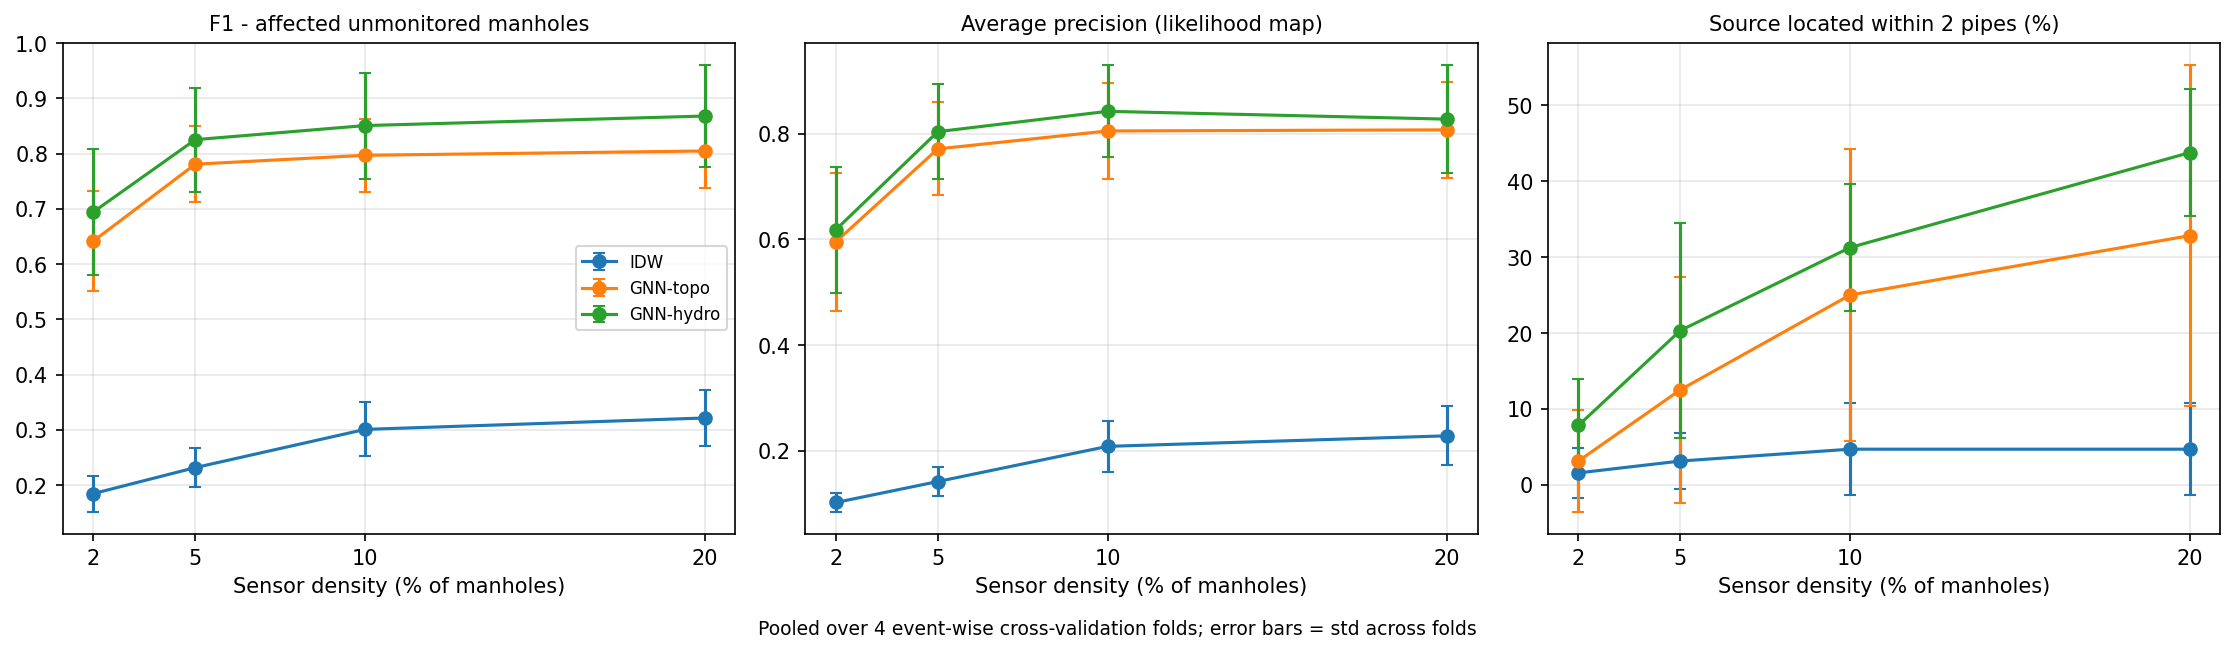

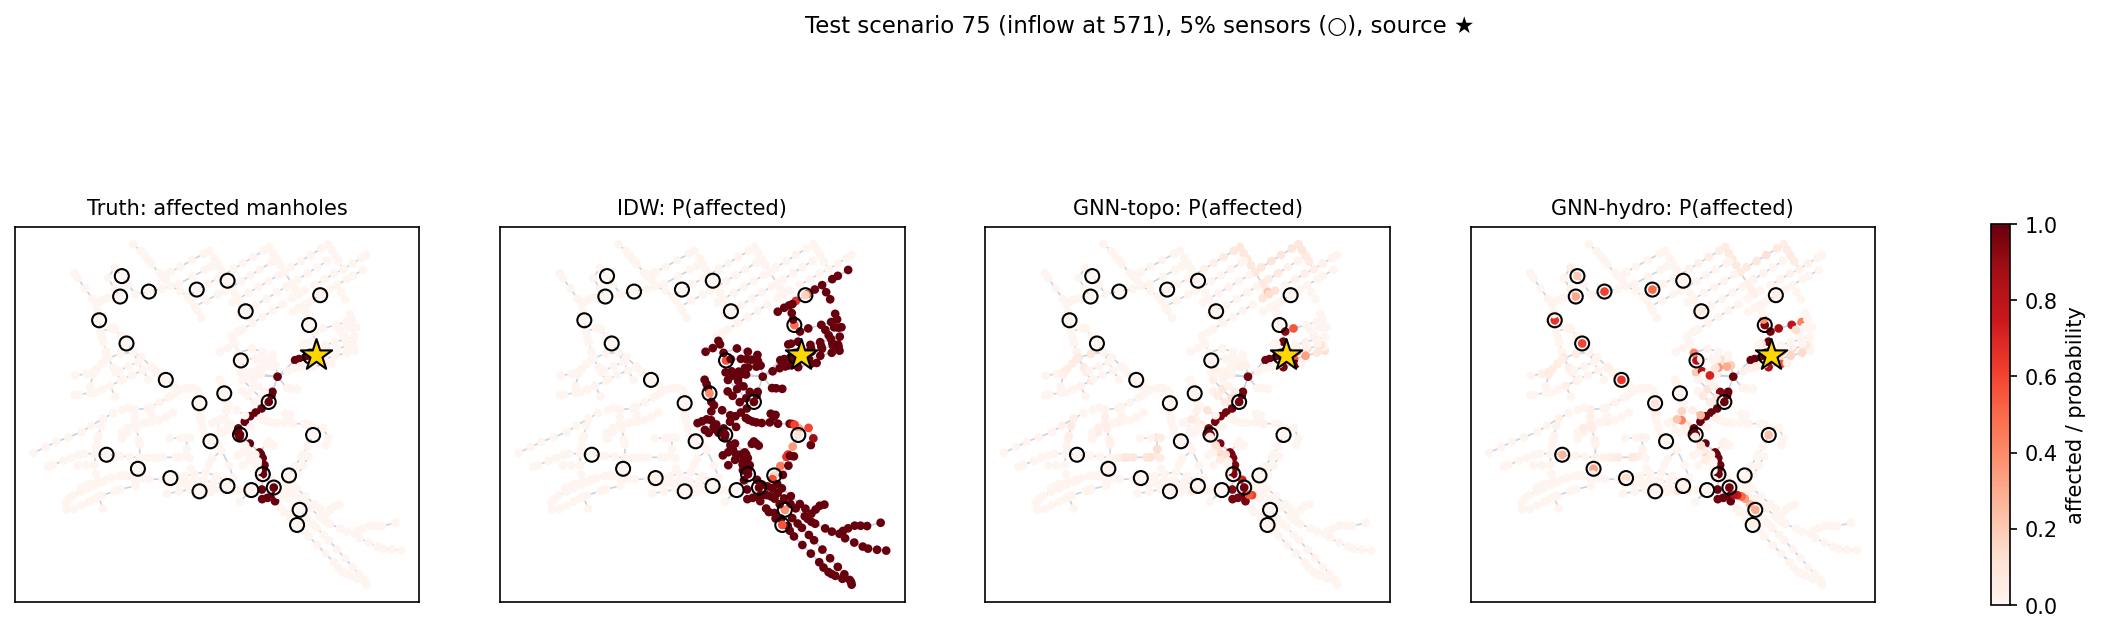

In [3]:
# Train + evaluate with 4-fold event-wise cross-validation
# (GPU: roughly 15-30 min; CPU: a few hours - use the GPU runtime)
pooled, spread, comp = run_experiment()

import pandas as pd
from IPython.display import Image, display
cols = ["f1", "avg_precision", "false_alarm_normal", "loc_within_2_hops"]
print("\nPOOLED over all folds - test disturbances, unmonitored manholes:")
display(pooled.pivot(index="density", columns="method", values=cols).round(3))
print("\nGNN-hydro vs GNN-topo - paired bootstrap over test disturbances "
      "(diff > 0 favours GNN-hydro; p = share of resamples where hydro is not better):")
display(comp.round(3))
for f in ("results_by_density.png", "example_likelihood_map.png"):
    display(Image(filename=str(OUT_DIR / f), width=1000))


## Redraw the example map (no retraining)
Uses the saved fold models in `ouseburn_gnn/`. Run the settings cell first if the session restarted.
`scenario_id=None` picks a typical test disturbance (median affected size) - prefer typical cases over best-looking ones for the slides.

In [ ]:
from IPython.display import Image, display

path = replot_example()                       # typical case, headline 5 % sensors
# path = replot_example(scenario_id=75)       # a specific test scenario
# path = replot_example(scenario_id=75, density=0.10, fname="example_75_10pct.png")
display(Image(filename=str(path), width=1100))
